# Fase 1 — Carregamento e Análise Exploratória de Imagens (EDA)

Nesta etapa será realizado o carregamento do dataset MNIST e uma análise inicial da estrutura dos dados.

Serão avaliados:
- dimensionalidade das matrizes X e y;
- distribuição das classes de 0 a 9;
- visualização de exemplos das imagens;
- representação das imagens 28 x 28 como 784 features;
- escala de intensidade dos pixels.


In [77]:
# Importação das bibliotecas necessárias.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Biblioteca utilizada para medir o tempo de treinamento dos modelos.
import time

# Importa a função utilizada para carregar o dataset MNIST.
from sklearn.datasets import fetch_openml

# Importa a função utilizada para dividir os dados.
from sklearn.model_selection import train_test_split

# Importa o algoritmo KNN.
from sklearn.neighbors import KNeighborsClassifier

# Importa o algoritmo Random Forest para classificação.
from sklearn.ensemble import RandomForestClassifier

# Importa a rede neural Multilayer Perceptron para classificação.
from sklearn.neural_network import MLPClassifier

# Importa as métricas utilizadas na avaliação final dos modelos.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [ ]:
# Carregar o dataset MNIST a partir do OpenML utilizando a função fetch_openml.

print("Baixando o dataset MNIST...")

mnist = fetch_openml(
    'mnist_784',
    version=1,
    as_frame=False,
    parser='auto'
)

X = mnist.data.astype(np.float32)
y = mnist.target.astype(np.uint8)

print(f'Formato de X: {X.shape}')
print(f'Formato de y: {y.shape}')
print(f'Faixa original dos pixels: {X.min():.0f} a {X.max():.0f}')

print("Dataset MNIST baixado com sucesso!")

In [30]:
# Identifica as classes únicas em y e conta quantas vezes cada uma aparece.
classes, contagens = np.unique(y, return_counts=True)

# Organiza os resultados em um DataFrame do Pandas.
df_distribuicao = pd.DataFrame({
    'digito': classes,
    'quantidade': contagens
})

# Calcula o percentual de cada classe em relação ao total de imagens.
df_distribuicao['percentual'] = (
    df_distribuicao['quantidade'] / len(y) * 100
).round(2)

# Define a coluna "digito" como índice.
df_distribuicao = df_distribuicao.set_index('digito')

df_distribuicao

,quantidade,percentual
digito,,
0,6903,9.86
1,7877,11.25
2,6990,9.99
3,7141,10.20
4,6824,9.75
5,6313,9.02
6,6876,9.82
7,7293,10.42
8,6825,9.75


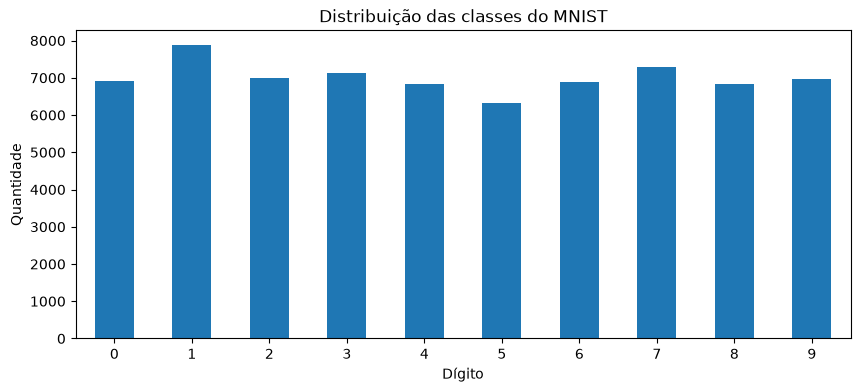

In [31]:
# Gera um gráfico de barras para facilitar a comparação visual das classes.
ax = df_distribuicao['quantidade'].plot.bar(figsize=(10, 4))

# Adiciona título e nomes aos eixos do gráfico.
ax.set(
    title='Distribuição das classes do MNIST',
    xlabel='Dígito',
    ylabel='Quantidade'
)

# Mantém os rótulos de 0 a 9 na horizontal.
ax.tick_params(axis='x', rotation=0)

# Exibe o gráfico.
plt.show()

### Análise da distribuição das classes

As quantidades de imagens entre os dígitos de 0 a 9 são relativamente próximas. Os percentuais ficam próximos de 10% por classe, indicando que o dataset MNIST apresenta uma distribuição relativamente balanceada entre as classes.

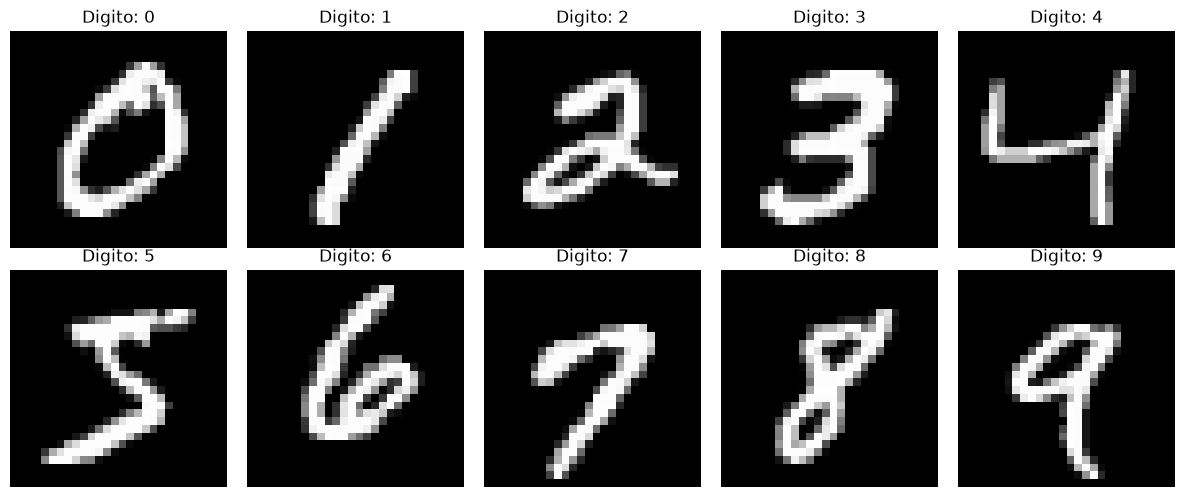

In [22]:
# Cria uma figura com 2 linhas e 5 colunas.
fig, axes = plt.subplots(2,5, figsize=(12,5))

# Percorre os dígitos de 0 a 9.

for digito in range(10):

     # Encontra a posição da primeira ocorrência desse dígito em y.
     indice = np.where(y == digito)[0][0]

     # Recupera a imagem correspondente e reorganiza para 28 x 28.
     imagem = X[indice].reshape(28, 28)

     # Define em qual posição da grade a imagem será exibida.
     eixo = axes.flat[digito]

     # Exibe a imagem em escala de cinza.
     eixo.imshow(imagem, cmap= 'gray')

     # Exibe o rótulo verdadeiro como título.
     eixo.set_title(f'Digito: {y[indice]}')

     # Remove os eixos para facilitar a visualização.
     eixo.axis('off')


# Ajusta o espaçamento entre as imagens.
plt.tight_layout()

# Exibe a grade completa.
plt.show()






### Interpretação da estrutura dos dados

O dataset MNIST possui 70.000 imagens de dígitos manuscritos. Cada imagem possui dimensão de 28 x 28 pixels, totalizando 784 pixels por imagem.

Para os modelos de Machine Learning, cada imagem é representada de forma vetorial, ou seja, os 784 pixels são organizados como 784 características (features) de entrada.

Os valores dos pixels variam de 0 a 255 e representam a intensidade de cada pixel na imagem em escala de cinza. Dessa forma, o modelo utiliza os valores numéricos dos pixels para aprender padrões que diferenciam os dígitos de 0 a 9.

# Fase 2 — Pipeline de Pré-processamento e Divisão dos Dados

Nesta etapa será realizado o pré-processamento dos dados do MNIST e a divisão do conjunto em subconjuntos de treino, validação e teste.

Serão avaliados:
- divisão dos dados em treino, validação e teste;
- uso de estratificação para preservar a proporção das classes;
- normalização dos valores dos pixels;
- verificação das dimensões dos subconjuntos gerados;
- justificativa da importância do pré-processamento para os modelos de Machine Learning.

In [36]:
# Importa a função utilizada para dividir os dados em subconjuntos.
from sklearn.model_selection import train_test_split

# Divide o conjunto completo em treino/validação e teste.
# 20% dos dados são reservados para o teste final.
X_treino_validacao, X_teste, y_treino_validacao, y_teste = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [37]:
# Divide o conjunto de treino/validação em treino e validação.
# 12,5% dos 80% restantes correspondem a 10% do dataset original.
X_treino, X_validacao, y_treino, y_validacao = train_test_split(
    X_treino_validacao,
    y_treino_validacao,
    test_size=0.125,
    stratify=y_treino_validacao,
    random_state=42
)

In [39]:
# Cria uma tabela para conferir a quantidade e o percentual de dados em cada subconjunto.
df_divisao = pd.DataFrame({
    'conjunto': ['Treino', 'Validação', 'Teste'],
    'quantidade': [
        len(X_treino),
        len(X_validacao),
        len(X_teste)
    ]
})

# Calcula o percentual de cada conjunto em relação ao total.
df_divisao['percentual'] = (
    df_divisao['quantidade'] / len(X) *100
).round(2)

# Define a coluna "conjunto" como índice.
df_divisao = df_divisao.set_index('conjunto')

# Exibe a tabela.
df_divisao

,quantidade,percentual
conjunto,,
Treino,49000,70.0
Validação,7000,10.0
Teste,14000,20.0


In [40]:
# Normaliza os valores dos pixels para o intervalo entre 0.0 e 1.0.
X_treino = X_treino / 255.0
X_validacao = X_validacao /255.0
X_teste = X_teste / 255.0

In [ ]:
# Cria uma tabela para verificar os valores mínimo e máximodos pixels após a normalização.

df_normalizacao = pd.DataFrame({
    'conjunto': ['Treino', 'Validação', 'Teste'],
    'valor_minimo': [
        X_treino.min(),
        X_validacao.min(),
        X_teste.min()
    ],
    'valor_maximo': [
        X_treino.max(),
        X_validacao.max(),
        X_teste.max()
    ]
})

# Define a coluna "conjunto" como índice.
df_normalizacao = df_normalizacao.set_index('conjunto')

# Exibe a tabela.
df_normalizacao

,valor_minimo,valor_maximo
conjunto,,
Treino,0.0,1.0
Validação,0.0,1.0
Teste,0.0,1.0


### Normalização dos dados

Os valores dos pixels originalmente variam entre 0 e 255. Nesta etapa, os dados foram normalizados para o intervalo entre 0.0 e 1.0 por meio da divisão dos valores por 255.0.

A normalização mantém a relação entre as intensidades dos pixels, mas reduz sua escala numérica. Esse pré-processamento é importante principalmente para modelos que utilizam cálculos de distância ou processos de otimização, pois facilita o tratamento dos valores durante o treinamento.

# Fase 3 — Implementação e Treinamento dos Modelos

Nesta etapa serão implementados e avaliados três modelos distintos de classificação para reconhecimento dos dígitos do dataset MNIST.

Os modelos escolhidos são:
- K-Nearest Neighbors (KNN);
- Random Forest;
- Multilayer Perceptron (MLP).

Para cada modelo serão avaliadas diferentes configurações de hiperparâmetros, buscando comparar seu comportamento e desempenho.

## 1. K-Nearest Neighbors (KNN)

O KNN classifica uma nova amostra com base nos exemplos mais próximos do conjunto de treino.

Para cada nova imagem, o algoritmo calcula quais amostras estão mais próximas e utiliza essas vizinhas para decidir qual dígito será previsto.

Neste projeto, serão avaliados dois hiperparâmetros principais:

- `n_neighbors`: define quantos vizinhos mais próximos serão considerados na decisão.
- `weights`: define como os vizinhos influenciam a classificação. Com `uniform`, todos possuem o mesmo peso; com `distance`, os vizinhos mais próximos possuem maior influência.

Serão comparadas diferentes combinações desses hiperparâmetros utilizando o conjunto de validação.

In [63]:
# Define as combinações de hiperparâmetros que serão avaliadas no KNN.
configuracoes_Knn = [
    {'n_neighbors': 3, 'weights': 'uniform'},
    {'n_neighbors': 3, 'weights': 'distance'},
    {'n_neighbors': 5, 'weights': 'uniform'},
    {'n_neighbors': 5, 'weights': 'distance'}   
]

In [64]:
# Lista que armazenará os resultados obtidos por cada configuração do KNN.
resultados_knn = []

# Percorre cada combinação de hiperparâmetros definida anteriormente.
for configuracao in configuracoes_Knn:

    # Cria o modelo KNN com a configuração atual.
    modelo_knn = KNeighborsClassifier(
        n_neighbors=configuracao['n_neighbors'],
        weights=configuracao['weights']
    )

    # Mede o tempo de treinamento.
    inicio_treino = time.perf_counter()

    modelo_knn.fit(X_treino, y_treino)

    tempo_treino = time.perf_counter() - inicio_treino

    # Mede o tempo necessário para realizar as previsões.
    inicio_predicao = time.perf_counter()

    y_pred_validacao = modelo_knn.predict(X_validacao)

    tempo_predicao = time.perf_counter() - inicio_predicao

    # Calcula a acurácia no conjunto de validação.
    acuracia_validacao = accuracy_score(
        y_validacao,
        y_pred_validacao
    )

    # Armazena os resultados.
    resultados_knn.append({
        'n_neighbors': configuracao['n_neighbors'],
        'weights': configuracao['weights'],
        'acuracia_validacao': acuracia_validacao,
        'tempo_treino_segundos': tempo_treino,
        'tempo_predicao_segundos': tempo_predicao
    })

In [65]:
# Organiza os resultados das configurações em um DataFrame.
df_resultados_knn = pd.DataFrame(resultados_knn)

# Converte a acurácia para percentual.
df_resultados_knn['acuracia_validacao'] = (
    df_resultados_knn['acuracia_validacao'] * 100
).round(2)

# Arredonda o tempo de treinamento.
df_resultados_knn['tempo_treino_segundos'] = (
    df_resultados_knn['tempo_treino_segundos']
).round(4)

# Arredonda o tempo de predição.
df_resultados_knn['tempo_predicao_segundos'] = (
    df_resultados_knn['tempo_predicao_segundos']
).round(4)

# Ordena as configurações da maior para a menor acurácia.
df_resultados_knn = df_resultados_knn.sort_values(
    by='acuracia_validacao',
    ascending=False
).reset_index(drop=True)

# Exibe os resultados.
df_resultados_knn

,n_neighbors,weights,acuracia_validacao,tempo_treino_segundos,tempo_predicao_segundos
0,3,distance,97.23,0.0126,3.6765
1,3,uniform,97.19,0.0200,3.9957
2,5,distance,97.14,0.0139,3.8458
3,5,uniform,96.94,0.0121,3.9616


In [66]:
# Seleciona a configuração que apresentou a maior acurácia na validação.
melhor_configuracao_knn = df_resultados_knn.iloc[0]

# Organiza a melhor configuração em formato de DataFrame.
df_melhor_knn = pd.DataFrame({
    'modelo': ['KNN'],
    'n_neighbors': [melhor_configuracao_knn['n_neighbors']],
    'weights': [melhor_configuracao_knn['weights']],
    'acuracia_validacao': [melhor_configuracao_knn['acuracia_validacao']],
    'tempo_treino_segundos': [melhor_configuracao_knn['tempo_treino_segundos']],
    'tempo_predicao_segundos': [melhor_configuracao_knn['tempo_predicao_segundos']]
})

# Define a coluna "modelo" como índice.
df_melhor_knn = df_melhor_knn.set_index('modelo')

# Exibe a melhor configuração.
df_melhor_knn

,n_neighbors,weights,acuracia_validacao,tempo_treino_segundos,tempo_predicao_segundos
modelo,,,,,
KNN,3,distance,97.23,0.0126,3.6765


### Análise do KNN

As diferentes configurações do KNN apresentaram resultados próximos no conjunto de validação.

A melhor configuração foi obtida com `n_neighbors = 3` e `weights = 'distance'`, alcançando acurácia de validação de **97,23%**.

Nos testes realizados, o uso de `weights = 'distance'` apresentou desempenho ligeiramente superior ao `weights = 'uniform'` para os valores de K avaliados. Além disso, `n_neighbors = 3` apresentou resultados um pouco melhores que `n_neighbors = 5`.

A diferença entre as configurações foi pequena, indicando que o modelo apresentou desempenho consistente entre os hiperparâmetros testados.

A configuração com `n_neighbors = 3` e `weights = 'distance'` será utilizada como melhor configuração do KNN para as próximas etapas de avaliação.

## 2. Random Forest

O Random Forest é um algoritmo de classificação baseado na combinação de várias árvores de decisão.

Cada árvore realiza suas próprias decisões a partir dos dados e, ao final, o Random Forest combina os resultados dessas árvores para definir a classe prevista.

Neste projeto serão avaliados dois hiperparâmetros:

- `n_estimators`: define a quantidade de árvores utilizadas pelo modelo.
- `max_depth`: define a profundidade máxima que cada árvore pode atingir.

Uma quantidade maior de árvores pode tornar as previsões mais estáveis, mas também pode aumentar o custo computacional. Já `max_depth` controla a complexidade das árvores e pode ajudar a reduzir o risco de overfitting.

As diferentes configurações serão comparadas utilizando o conjunto de validação.

In [68]:
# Define as combinações de hiperparâmetros que serão avaliadas no Random Forest.

configuracoes_rf = [
    {'n_estimators': 50, 'max_depth': 10},
    {'n_estimators': 50, 'max_depth': None},
    {'n_estimators': 100, 'max_depth': 10},
    {'n_estimators': 100, 'max_depth': None}
]

In [69]:
# Lista que armazenará os resultados obtidos por cada configuração do Random Forest.
resultados_rf = []

# Percorre cada combinação de hiperparâmetros definida anteriormente.
for configuracao in configuracoes_rf:

    # Cria o modelo Random Forest com a configuração atual.
    modelo_rf = RandomForestClassifier(
        n_estimators=configuracao['n_estimators'],
        max_depth=configuracao['max_depth'],
        random_state=42,
        n_jobs=-1
    )

    # Mede o tempo de treinamento.
    inicio_treino = time.perf_counter()

    # Treina o modelo utilizando o conjunto de treino.
    modelo_rf.fit(X_treino, y_treino)

    # Calcula o tempo utilizado no treinamento.
    tempo_treino = time.perf_counter() - inicio_treino

    # Mede o tempo necessário para realizar as previsões.
    inicio_predicao = time.perf_counter()

    # Realiza previsões utilizando o conjunto de validação.
    y_pred_validacao = modelo_rf.predict(X_validacao)

    # Calcula o tempo utilizado na predição.
    tempo_predicao = time.perf_counter() - inicio_predicao

    # Calcula a acurácia obtida no conjunto de validação.
    acuracia_validacao = accuracy_score(
        y_validacao,
        y_pred_validacao
    )

    # Armazena os hiperparâmetros e os resultados obtidos.
    resultados_rf.append({
        'n_estimators': configuracao['n_estimators'],
        'max_depth': configuracao['max_depth'],
        'acuracia_validacao': acuracia_validacao,
        'tempo_treino_segundos': tempo_treino,
        'tempo_predicao_segundos': tempo_predicao
    })

In [70]:
# Organiza os resultados das configurações em um DataFrame.
df_resultados_rf = pd.DataFrame(resultados_rf)

# Converte a acurácia para percentual.
df_resultados_rf['acuracia_validacao'] = (
    df_resultados_rf['acuracia_validacao'] * 100
).round(2)

# Arredonda o tempo de treinamento.
df_resultados_rf['tempo_treino_segundos'] = (
    df_resultados_rf['tempo_treino_segundos']
).round(4)

# Arredonda o tempo de predição.
df_resultados_rf['tempo_predicao_segundos'] = (
    df_resultados_rf['tempo_predicao_segundos']
).round(4)

# Ordena as configurações da maior para a menor acurácia.
df_resultados_rf = df_resultados_rf.sort_values(
    by='acuracia_validacao',
    ascending=False
).reset_index(drop=True)

# Exibe os resultados.
df_resultados_rf

,n_estimators,max_depth,acuracia_validacao,tempo_treino_segundos,tempo_predicao_segundos
0,100,NaN,96.61,5.1071,0.0604
1,50,NaN,96.50,2.9681,0.0535
2,100,10.0,94.64,4.0646,0.0610
3,50,10.0,94.46,2.1145,0.0270


In [71]:
# Seleciona a configuração que apresentou a maior acurácia na validação.
melhor_configuracao_rf = df_resultados_rf.iloc[0]

# Organiza a melhor configuração em formato de DataFrame.
df_melhor_rf = pd.DataFrame({
    'modelo': ['Random Forest'],
    'n_estimators': [melhor_configuracao_rf['n_estimators']],
    'max_depth': [melhor_configuracao_rf['max_depth']],
    'acuracia_validacao': [melhor_configuracao_rf['acuracia_validacao']],
    'tempo_treino_segundos': [melhor_configuracao_rf['tempo_treino_segundos']],
    'tempo_predicao_segundos': [melhor_configuracao_rf['tempo_predicao_segundos']]
})

# Define a coluna "modelo" como índice.
df_melhor_rf = df_melhor_rf.set_index('modelo')

# Exibe a melhor configuração.
df_melhor_rf

,n_estimators,max_depth,acuracia_validacao,tempo_treino_segundos,tempo_predicao_segundos
modelo,,,,,
Random Forest,100.0,NaN,96.61,5.1071,0.0604


### Análise do Random Forest

As diferentes configurações do Random Forest apresentaram diferenças relevantes de desempenho no conjunto de validação.

A melhor configuração utilizou `n_estimators = 100` e `max_depth = None`, alcançando acurácia de validação de **96,61%**.

Nos experimentos realizados, as configurações sem limite explícito de profundidade apresentaram resultados superiores às configurações com `max_depth = 10`. Isso indica que limitar as árvores a essa profundidade reduziu a capacidade do modelo de representar os padrões presentes nos dados.

O aumento de 50 para 100 árvores gerou uma pequena melhora na acurácia, porém também aumentou o tempo de treinamento. Dessa forma, a configuração com 100 árvores apresentou o melhor desempenho, mas com maior custo computacional.

A configuração com `n_estimators = 100` e `max_depth = None` será utilizada como melhor configuração do Random Forest nas próximas etapas de avaliação.

## 3. Multilayer Perceptron (MLP)

O Multilayer Perceptron (MLP) é uma rede neural artificial composta por uma camada de entrada, uma ou mais camadas ocultas e uma camada de saída.

No MNIST, os 784 valores dos pixels são utilizados como entradas da rede. Durante o treinamento, o modelo ajusta pesos internos para aprender padrões que ajudam a diferenciar os dígitos de 0 a 9.

Neste projeto serão avaliados dois hiperparâmetros principais:

- `hidden_layer_sizes`: define a quantidade de neurônios e a estrutura das camadas ocultas.
- `alpha`: controla a regularização do modelo, ajudando a reduzir o risco de overfitting.

As diferentes configurações serão comparadas utilizando o conjunto de validação.

In [73]:
# Define as combinações de hiperparâmetros que serão avaliadas no MLP.

configuracoes_mlp = [
    {'hidden_layer_sizes': (64,), 'alpha': 0.0001},
    {'hidden_layer_sizes': (64,), 'alpha': 0.001},
    {'hidden_layer_sizes': (128,), 'alpha': 0.0001},
    {'hidden_layer_sizes': (128,), 'alpha': 0.001}
]

In [ ]:
# Lista que armazenará os resultados obtidos por cada configuração do MLP.
resultados_mlp = []

# Percorre cada combinação de hiperparâmetros definida anteriormente.
for configuracao in configuracoes_mlp:

    # Cria o modelo MLP com a configuração atual.
    modelo_mlp = MLPClassifier(
        hidden_layer_sizes=configuracao['hidden_layer_sizes'],
        alpha=configuracao['alpha'],
        max_iter=20,
        random_state=42
    )

    # Mede o tempo de treinamento.
    inicio_treino = time.perf_counter()

    # Treina o modelo utilizando o conjunto de treino.
    modelo_mlp.fit(X_treino, y_treino)

    # Calcula o tempo utilizado no treinamento.
    tempo_treino = time.perf_counter() - inicio_treino

    # Mede o tempo necessário para realizar as previsões.
    inicio_predicao = time.perf_counter()

    # Realiza previsões utilizando o conjunto de validação.
    y_pred_validacao = modelo_mlp.predict(X_validacao)

    # Calcula o tempo utilizado na predição.
    tempo_predicao = time.perf_counter() - inicio_predicao

    # Calcula a acurácia obtida no conjunto de validação.
    acuracia_validacao = accuracy_score(
        y_validacao,
        y_pred_validacao
    )

    # Armazena os hiperparâmetros e os resultados obtidos.
    resultados_mlp.append({
        'hidden_layer_sizes': configuracao['hidden_layer_sizes'],
        'alpha': configuracao['alpha'],
        'acuracia_validacao': acuracia_validacao,
        'tempo_treino_segundos': tempo_treino,
        'tempo_predicao_segundos': tempo_predicao
    })

In [75]:
# Organiza os resultados das configurações em um DataFrame.
df_resultados_mlp = pd.DataFrame(resultados_mlp)

# Converte a acurácia para percentual.
df_resultados_mlp['acuracia_validacao'] = (
    df_resultados_mlp['acuracia_validacao'] * 100
).round(2)

# Arredonda o tempo de treinamento.
df_resultados_mlp['tempo_treino_segundos'] = (
    df_resultados_mlp['tempo_treino_segundos']
).round(4)

# Arredonda o tempo de predição.
df_resultados_mlp['tempo_predicao_segundos'] = (
    df_resultados_mlp['tempo_predicao_segundos']
).round(4)

# Ordena as configurações da maior para a menor acurácia.
df_resultados_mlp = df_resultados_mlp.sort_values(
    by='acuracia_validacao',
    ascending=False
).reset_index(drop=True)

# Exibe os resultados.
df_resultados_mlp

,hidden_layer_sizes,alpha,acuracia_validacao,tempo_treino_segundos,tempo_predicao_segundos
0,"(128,)",0.0010,97.41,23.3052,0.0173
1,"(128,)",0.0001,97.39,19.6452,0.0256
2,"(64,)",0.0001,97.06,11.8457,0.0184
3,"(64,)",0.0010,97.01,8.9362,0.0826


In [76]:
# Seleciona a configuração que apresentou a maior acurácia na validação.
melhor_configuracao_mlp = df_resultados_mlp.iloc[0]

# Organiza a melhor configuração em formato de DataFrame.
df_melhor_mlp = pd.DataFrame({
    'modelo': ['MLP'],
    'hidden_layer_sizes': [melhor_configuracao_mlp['hidden_layer_sizes']],
    'alpha': [melhor_configuracao_mlp['alpha']],
    'acuracia_validacao': [melhor_configuracao_mlp['acuracia_validacao']],
    'tempo_treino_segundos': [melhor_configuracao_mlp['tempo_treino_segundos']],
    'tempo_predicao_segundos': [melhor_configuracao_mlp['tempo_predicao_segundos']]
})

# Define a coluna "modelo" como índice.
df_melhor_mlp = df_melhor_mlp.set_index('modelo')

# Exibe a melhor configuração.
df_melhor_mlp

,hidden_layer_sizes,alpha,acuracia_validacao,tempo_treino_segundos,tempo_predicao_segundos
modelo,,,,,
MLP,"(128,)",0.001,97.41,23.3052,0.0173


### Análise do MLP

As diferentes configurações do MLP apresentaram bons resultados no conjunto de validação.

A melhor configuração utilizou uma camada oculta com 128 neurônios (`hidden_layer_sizes = (128,)`) e `alpha = 0.001`, alcançando acurácia de validação de **97,41%**.

Nos experimentos realizados, as configurações com 128 neurônios apresentaram desempenho superior às configurações com 64 neurônios. A diferença entre os valores de regularização (`alpha`) foi pequena, indicando que, entre os valores testados, a quantidade de neurônios teve maior impacto na acurácia.

A configuração com 128 neurônios também apresentou maior tempo de treinamento, mostrando uma relação entre aumento da capacidade do modelo e maior custo computacional.

Durante alguns treinamentos, o modelo atingiu o limite definido de 20 iterações antes da convergência completa. Esse limite foi mantido para controlar o custo computacional do experimento.

A configuração com `hidden_layer_sizes = (128,)` e `alpha = 0.001` será utilizada como melhor configuração do MLP nas próximas etapas de avaliação.

# Fase 4 — Avaliação Comparativa de Desempenho

Nesta etapa, as melhores configurações encontradas para KNN, Random Forest e MLP serão avaliadas utilizando o conjunto de teste independente.

Para cada modelo serão analisadas:

- Acurácia global (Accuracy);
- Precisão média ponderada (Precision);
- Revocação média ponderada (Recall);
- F1-Score ponderado;
- Matriz de confusão 10 x 10;
- Tempo de treinamento e predição.

O conjunto de teste será utilizado somente nesta avaliação final, após a escolha dos hiperparâmetros realizada com o conjunto de validação.

## Avaliação dos melhores modelos no conjunto de teste

A partir dos resultados obtidos no conjunto de validação, foram selecionadas as seguintes configurações:

- **KNN:** `n_neighbors = 3` e `weights = 'distance'`;
- **Random Forest:** `n_estimators = 100` e `max_depth = None`;
- **MLP:** `hidden_layer_sizes = (128,)` e `alpha = 0.001`.

Essas configurações serão novamente treinadas utilizando o conjunto de treino e avaliadas no conjunto de teste, que permaneceu separado durante a escolha dos hiperparâmetros.

In [78]:
# Cria os modelos finais utilizando as melhores configurações encontradas durante a etapa de validação.

modelo_final_knn = KNeighborsClassifier(
    n_neighbors=3,
    weights='distance'
)

modelo_final_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

modelo_final_mlp = MLPClassifier(
    hidden_layer_sizes=(128,),
    alpha=0.001,
    max_iter=20,
    random_state=42
)

In [81]:
# Função responsável por treinar e avaliar um modelo no conjunto de teste.

def avaliar_modelo(nome_modelo, modelo, X_treino, y_treino, X_teste, y_teste):

    # Mede o tempo de treinamento.
    inicio_treino = time.perf_counter()

    modelo.fit(X_treino, y_treino)

    tempo_treino = time.perf_counter() - inicio_treino

    # Mede o tempo de predição.
    inicio_predicao = time.perf_counter()

    y_pred = modelo.predict(X_teste)

    tempo_predicao = time.perf_counter() - inicio_predicao

    # Calcula as métricas de avaliação.
    acuracia = accuracy_score(y_teste, y_pred)

    precisao = precision_score(
        y_teste,
        y_pred,
        average='weighted'
    )

    recall = recall_score(
        y_teste,
        y_pred,
        average='weighted'
    )

    f1 = f1_score(
        y_teste,
        y_pred,
        average='weighted'
    )

    # Calcula a matriz de confusão.
    matriz_confusao = confusion_matrix(
        y_teste,
        y_pred
    )

    # Retorna todos os resultados.
    return {
        'modelo': nome_modelo,
        'acuracia': acuracia,
        'precisao': precisao,
        'recall': recall,
        'f1_score': f1,
        'tempo_treino_segundos': tempo_treino,
        'tempo_predicao_segundos': tempo_predicao,
        'y_pred': y_pred,
        'matriz_confusao': matriz_confusao
    }

In [82]:
# Avalia cada modelo utilizando o conjunto de teste.

resultado_final_knn = avaliar_modelo(
    'KNN',
    modelo_final_knn,
    X_treino,
    y_treino,
    X_teste,
    y_teste
)

resultado_final_rf = avaliar_modelo(
    'Random Forest',
    modelo_final_rf,
    X_treino,
    y_treino,
    X_teste,
    y_teste
)

resultado_final_mlp = avaliar_modelo(
    'MLP',
    modelo_final_mlp,
    X_treino,
    y_treino,
    X_teste,
    y_teste
)

/home/thiago/Documentos/projeto-modulo-2-SCTEC/mini-projeto-mnist-sctec/projeto-mnist/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


In [83]:
# Organiza as métricas dos três modelos em uma tabela comparativa.

df_comparacao_final = pd.DataFrame([
    {
        'modelo': resultado_final_knn['modelo'],
        'acuracia': resultado_final_knn['acuracia'],
        'precisao': resultado_final_knn['precisao'],
        'recall': resultado_final_knn['recall'],
        'f1_score': resultado_final_knn['f1_score'],
        'tempo_treino_segundos': resultado_final_knn['tempo_treino_segundos'],
        'tempo_predicao_segundos': resultado_final_knn['tempo_predicao_segundos']
    },
    {
        'modelo': resultado_final_rf['modelo'],
        'acuracia': resultado_final_rf['acuracia'],
        'precisao': resultado_final_rf['precisao'],
        'recall': resultado_final_rf['recall'],
        'f1_score': resultado_final_rf['f1_score'],
        'tempo_treino_segundos': resultado_final_rf['tempo_treino_segundos'],
        'tempo_predicao_segundos': resultado_final_rf['tempo_predicao_segundos']
    },
    {
        'modelo': resultado_final_mlp['modelo'],
        'acuracia': resultado_final_mlp['acuracia'],
        'precisao': resultado_final_mlp['precisao'],
        'recall': resultado_final_mlp['recall'],
        'f1_score': resultado_final_mlp['f1_score'],
        'tempo_treino_segundos': resultado_final_mlp['tempo_treino_segundos'],
        'tempo_predicao_segundos': resultado_final_mlp['tempo_predicao_segundos']
    }
])

# Converte as métricas para percentual.
colunas_metricas = [
    'acuracia',
    'precisao',
    'recall',
    'f1_score'
]

df_comparacao_final[colunas_metricas] = (
    df_comparacao_final[colunas_metricas] * 100
).round(2)

# Arredonda os tempos.
df_comparacao_final['tempo_treino_segundos'] = (
    df_comparacao_final['tempo_treino_segundos']
).round(4)

df_comparacao_final['tempo_predicao_segundos'] = (
    df_comparacao_final['tempo_predicao_segundos']
).round(4)

# Ordena da maior para a menor acurácia.
df_comparacao_final = df_comparacao_final.sort_values(
    by='acuracia',
    ascending=False
).reset_index(drop=True)

# Define o nome do modelo como índice.
df_comparacao_final = df_comparacao_final.set_index('modelo')

df_comparacao_final

,acuracia,precisao,recall,f1_score,tempo_treino_segundos,tempo_predicao_segundos
modelo,,,,,,
MLP,97.76,97.76,97.76,97.76,11.4402,0.0365
KNN,97.21,97.24,97.21,97.21,0.0285,6.9358
Random Forest,96.51,96.51,96.51,96.51,4.8586,0.1462


## Matrizes de Confusão

As matrizes de confusão permitem analisar com maior detalhe os acertos e erros de cada modelo.

Nas matrizes, as linhas representam as classes verdadeiras e as colunas representam as classes previstas pelo modelo.

Os valores presentes na diagonal principal correspondem às classificações corretas, enquanto os valores fora da diagonal indicam quais dígitos foram confundidos pelo modelo.

In [84]:
# Função utilizada para exibir a matriz de confusão de cada modelo.

def plotar_matriz_confusao(matriz, nome_modelo):

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        matriz,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False
    )

    plt.title(f'Matriz de Confusão - {nome_modelo}')
    plt.xlabel('Classe prevista')
    plt.ylabel('Classe verdadeira')

    plt.show()

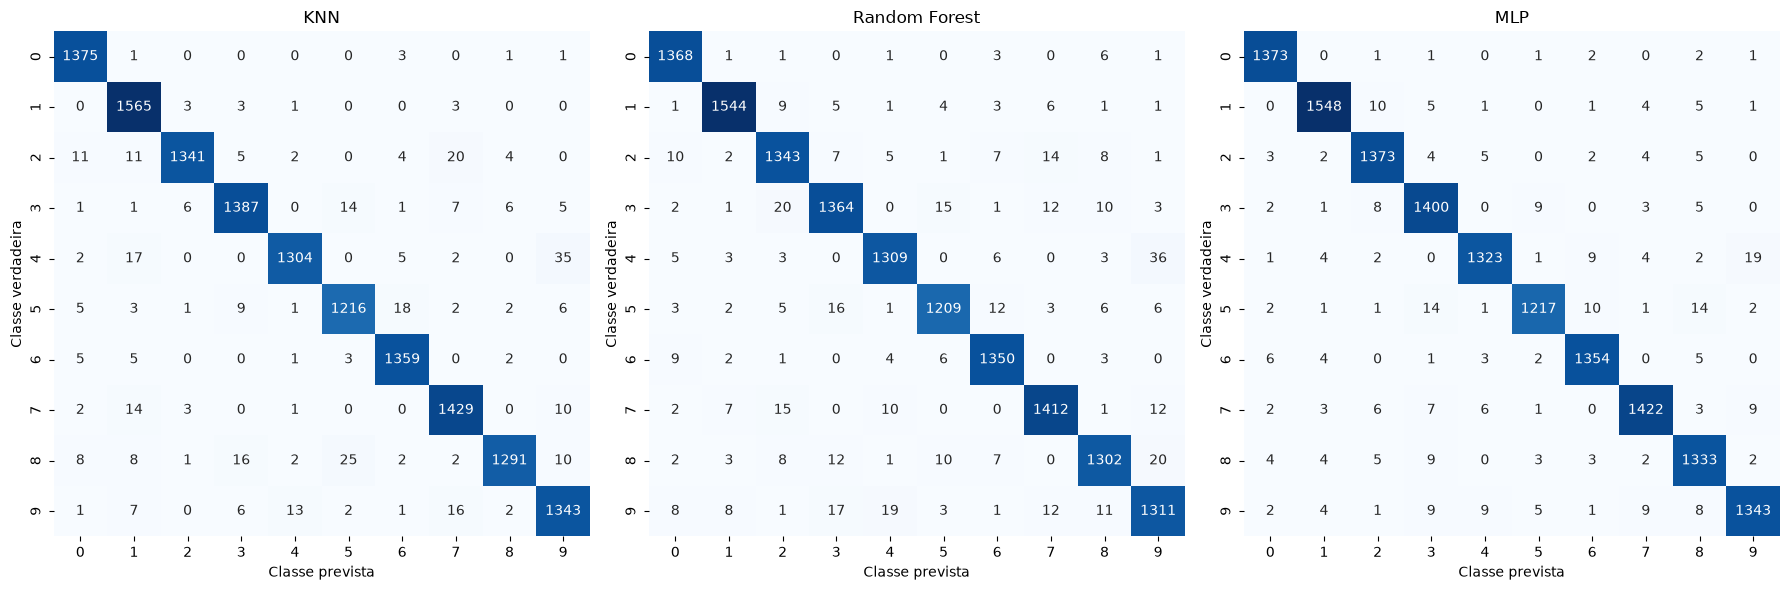

In [92]:
# Exibe as matrizes de confusão dos três modelos lado a lado.

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Matriz de confusão do KNN
sns.heatmap(
    resultado_final_knn['matriz_confusao'],
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    ax=axes[0]
)
axes[0].set_title('KNN')
axes[0].set_xlabel('Classe prevista')
axes[0].set_ylabel('Classe verdadeira')

# Matriz de confusão do Random Forest
sns.heatmap(
    resultado_final_rf['matriz_confusao'],
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    ax=axes[1]
)
axes[1].set_title('Random Forest')
axes[1].set_xlabel('Classe prevista')
axes[1].set_ylabel('Classe verdadeira')

# Matriz de confusão do MLP
sns.heatmap(
    resultado_final_mlp['matriz_confusao'],
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    ax=axes[2]
)
axes[2].set_title('MLP')
axes[2].set_xlabel('Classe prevista')
axes[2].set_ylabel('Classe verdadeira')

plt.tight_layout()
plt.show()

### Análise das matrizes de confusão

As três matrizes de confusão apresentam forte concentração de valores na diagonal principal, indicando que os modelos classificaram corretamente a maior parte das imagens do conjunto de teste.

O **MLP apresentou o melhor desempenho geral**, com acurácia, precisão, recall e F1-score de aproximadamente **97,76%**, além de apresentar menos erros fora da diagonal quando comparado aos demais modelos.

O **KNN** também apresentou bom desempenho, alcançando **97,21% de acurácia**. Entre suas maiores confusões, destacam-se imagens do dígito **4 classificadas como 9**, com 35 ocorrências, além de casos do dígito **8 classificados como 5** e do dígito **2 classificados como 7**.

O **Random Forest** apresentou acurácia de **96,51%**, sendo o modelo com menor desempenho entre os três avaliados. Sua maior confusão também ocorreu entre os dígitos **4 e 9**, com 36 imagens do dígito 4 classificadas como 9. Também foram observadas confusões entre os dígitos **3 e 2** e entre **9 e 4**.

No **MLP**, a maior confusão também ocorreu entre os dígitos **4 e 9**, porém em menor quantidade, com 19 casos. Outras confusões relevantes ocorreram entre o dígito **5 e os dígitos 3 e 8**.

De forma geral, os resultados mostram que alguns dígitos com formatos visuais semelhantes podem ser confundidos pelos modelos. Entre os três modelos avaliados, o MLP apresentou o melhor equilíbrio entre as métricas e a menor quantidade de erros de classificação.

In [93]:
# Função para identificar as maiores confusões de cada modelo.

def identificar_maiores_confusoes(matriz, nome_modelo, quantidade=5):

    # Cria uma cópia da matriz para preservar a matriz original.
    matriz_erros = matriz.copy()

    # Remove os valores da diagonal principal,
    # pois eles representam classificações corretas.
    np.fill_diagonal(matriz_erros, 0)

    # Lista que armazenará as confusões encontradas.
    confusoes = []

    # Percorre todas as posições da matriz.
    for classe_real in range(matriz_erros.shape[0]):
        for classe_prevista in range(matriz_erros.shape[1]):

            quantidade_erros = matriz_erros[classe_real, classe_prevista]

            # Armazena apenas posições em que ocorreu algum erro.
            if quantidade_erros > 0:
                confusoes.append({
                    'modelo': nome_modelo,
                    'classe_real': classe_real,
                    'classe_prevista': classe_prevista,
                    'quantidade_erros': quantidade_erros
                })

    # Organiza os resultados em um DataFrame.
    df_confusoes = pd.DataFrame(confusoes)

    # Ordena da maior para a menor quantidade de erros.
    df_confusoes = df_confusoes.sort_values(
        by='quantidade_erros',
        ascending=False
    ).head(quantidade)

    return df_confusoes

In [94]:
# Identifica as cinco maiores confusões de cada modelo.

df_confusoes_knn = identificar_maiores_confusoes(
    resultado_final_knn['matriz_confusao'],
    'KNN'
)

df_confusoes_rf = identificar_maiores_confusoes(
    resultado_final_rf['matriz_confusao'],
    'Random Forest'
)

df_confusoes_mlp = identificar_maiores_confusoes(
    resultado_final_mlp['matriz_confusao'],
    'MLP'
)

# Junta os resultados dos três modelos.
df_maiores_confusoes = pd.concat([
    df_confusoes_knn,
    df_confusoes_rf,
    df_confusoes_mlp
])

# Organiza o índice.
df_maiores_confusoes = df_maiores_confusoes.reset_index(drop=True)

df_maiores_confusoes

,modelo,classe_real,classe_prevista,quantidade_erros
0,KNN,4,9,35
1,KNN,8,5,25
2,KNN,2,7,20
3,KNN,5,6,18
4,KNN,4,1,17
5,Random Forest,4,9,36
6,Random Forest,3,2,20
7,Random Forest,8,9,20
8,Random Forest,9,4,19
9,Random Forest,9,3,17


### Conclusão da Fase 4

Os três modelos apresentaram bom desempenho no conjunto de teste, com acurácia superior a 96%.

O **MLP apresentou o melhor resultado geral**, com acurácia, precisão, recall e F1-score de aproximadamente **97,76%**. O KNN apresentou desempenho muito próximo, com acurácia de **97,21%**, enquanto o Random Forest alcançou **96,51%**.

A análise das matrizes de confusão mostrou que os três modelos apresentaram maior concentração de valores na diagonal principal, indicando grande quantidade de classificações corretas.

Entre os principais erros observados, o KNN confundiu com maior frequência o dígito **4 com o 9**, em 35 casos. O Random Forest apresentou comportamento semelhante, com 36 imagens do dígito **4 classificadas como 9**. No MLP, essa mesma confusão também apareceu como a mais frequente, porém em menor quantidade, com 19 casos.

Outros erros relevantes incluíram confusões entre os dígitos **8 e 5** no KNN, **3 e 2** no Random Forest e **5 e 3** e **5 e 8** no MLP.

Em relação ao custo computacional, o **KNN apresentou treinamento muito rápido**, porém maior tempo de predição, pois precisa calcular distâncias entre as novas amostras e os exemplos do conjunto de treino. O **MLP apresentou maior tempo de treinamento**, mas realizou previsões rapidamente. O Random Forest apresentou comportamento intermediário entre os dois.

Dessa forma, considerando desempenho global, equilíbrio entre as métricas e menor quantidade de erros de classificação, o **MLP foi o modelo com melhor desempenho entre os três avaliados**.